In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib
import warnings



In [156]:
#.venv\Scripts\Activate
warnings.filterwarnings('ignore')

In [157]:
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [158]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [159]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: >

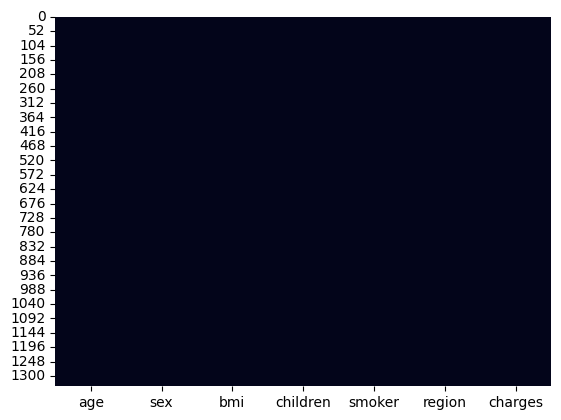

In [160]:
sns.heatmap(df.isna(),cbar=False)

<Axes: >

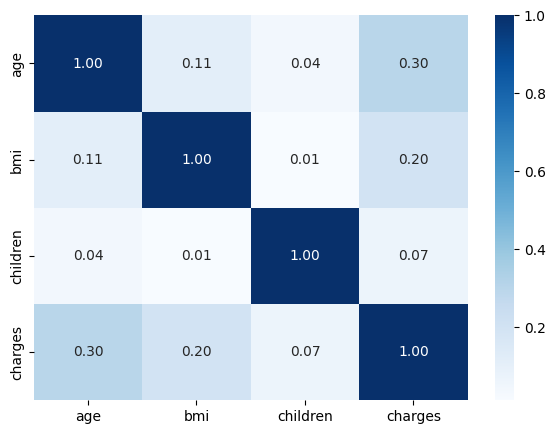

In [161]:
corr=df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,fmt='0.2f',cmap='Blues')

<Axes: xlabel='age', ylabel='Count'>

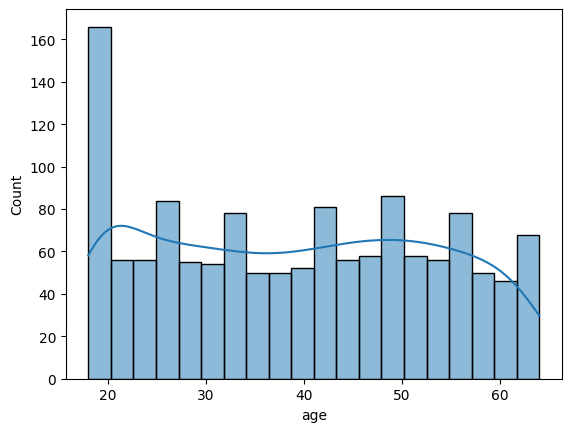

In [162]:
sns.histplot(x='age', data=df, bins=20, kde=True)

<Axes: xlabel='age', ylabel='Count'>

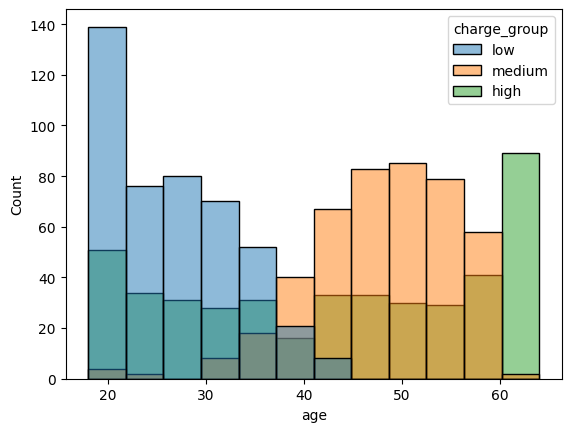

In [163]:
df['charge_group'] = pd.qcut(df['charges'], q=3, labels=['low','medium','high'])

sns.histplot(x='age', hue='charge_group', data=df)

<Axes: xlabel='age', ylabel='Density'>

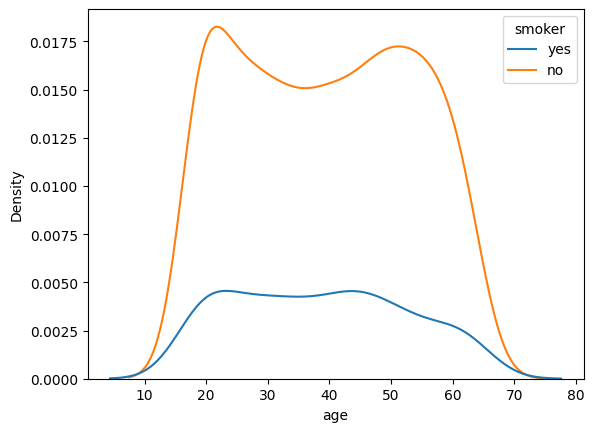

In [164]:
sns.kdeplot(x='age', hue='smoker', data=df)

In [165]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'charge_group'],
      dtype='str')

In [166]:
s=df.select_dtypes(include=['number'])
s.head(2)

,age,bmi,children,charges
0,19,27.90,0,16884.9240
1,18,33.77,1,1725.5523


In [167]:
df['bmi_age'] = df['bmi'] * df['age']
df['children_bmi'] = df['children'] * df['bmi']

In [168]:
x=df.drop(['charges','charge_group'],axis=1)
y=df['charges']

In [169]:
num_cols = ['age','bmi','children','bmi_age','children_bmi']
cat_cols=df.select_dtypes(include='object').columns
cat_cols

Index(['sex', 'smoker', 'region'], dtype='str')

In [170]:
pre= ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [171]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [172]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
}
run_models=[]

In [173]:
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('pre', pre),
        ('model', model)
    ])
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    run_models.append({'Model': name, 'RMSE': rmse, 'R2': r2})

models_out = pd.DataFrame(run_models).sort_values(by='R2', ascending=False)
print(models_out) 
    

              Model         RMSE        R2
2           XGBoost  4453.923953  0.872222
1      RandomForest  4487.594406  0.870282
0  LinearRegression  5844.561520  0.779973


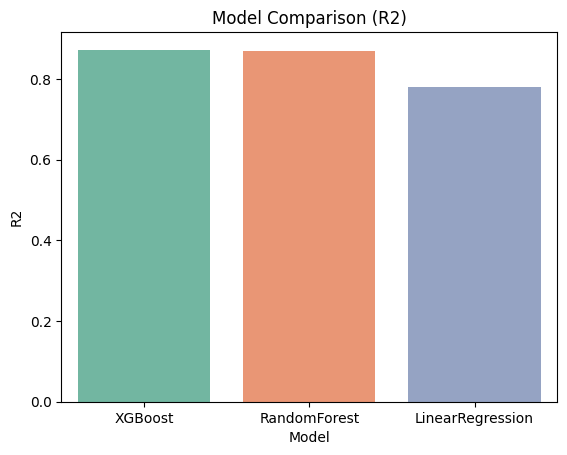

In [174]:
sns.barplot(x='Model', y='R2', data=models_out,palette='Set2')
plt.title("Model Comparison (R2)")
plt.show()

In [175]:
finish=Pipeline(steps=[
    ('pre', pre),
    ('model', XGBRegressor(random_state=42))
])

In [176]:
pa_g = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1]
}

In [177]:
grid =GridSearchCV(
    estimator=finish,
    param_grid=pa_g,
    cv=5,
    scoring='r2',
    n_jobs=2,
)


In [178]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [179]:
print("Best Params:", grid.best_params_)
print("Best R2:", grid.best_score_)

Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1}
Best R2: 0.8496270093394063


In [180]:
y_pred_train=grid.predict(x_train)
y_pred_test=grid.predict(x_test)

In [181]:
def metrics_regression(y_train, y_test, y_pred_train, y_pred_test):
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    print('-'*45)
    print(f'RMSE Train : {round(rmse_train,2)}')
    print(f'RMSE Test  : {round(rmse_test,2)}')
    print('-'*45)
    print(f'MAE Train  : {round(mae_train,2)}')
    print(f'MAE Test   : {round(mae_test,2)}')
    print('-'*45)
    print(f'R2 Train   : {round(r2_train,4)}')
    print(f'R2 Test    : {round(r2_test,4)}')
    print('-'*45)
metrics_regression(y_train, y_test, y_pred_train, y_pred_test)

---------------------------------------------
RMSE Train : 4110.33
RMSE Test  : 4224.06
---------------------------------------------
MAE Train  : 2275.51
MAE Test   : 2447.76
---------------------------------------------
R2 Train   : 0.8829
R2 Test    : 0.8851
---------------------------------------------


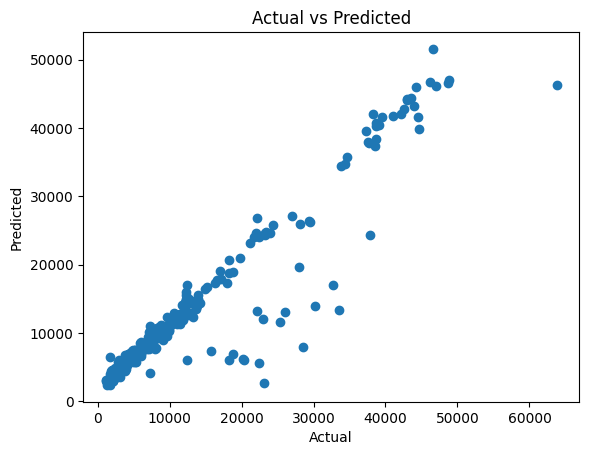

In [182]:
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

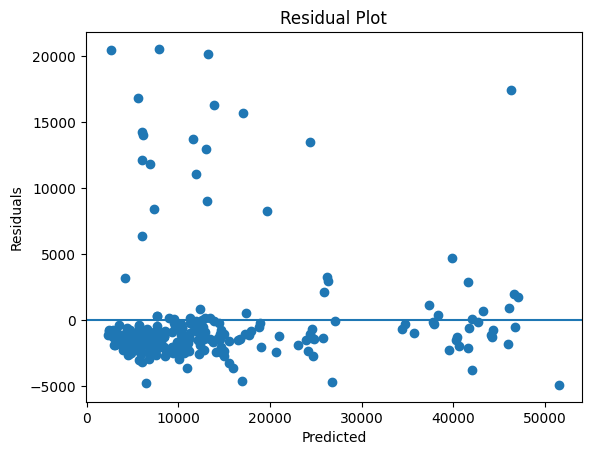

In [183]:
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [184]:
joblib.dump(grid.best_estimator_, "best_model.pkl")

['best_model.pkl']